In [15]:
import pandas as pd

# Load your data
df = pd.read_csv("AI_Dating_Study_Responses.csv")

# Quick check
print(df.head())


                    timestamp       participant_id  age gender attraction  \
0  2025-11-21T02:16:08.292876  PID_1763691360_7895   24    Man        Men   
1  2025-11-21T02:16:11.708219  PID_1763691360_7895   24    Man        Men   
2  2025-11-21T02:16:16.292425  PID_1763691360_7895   24    Man        Men   
3  2025-11-21T02:16:26.740862  PID_1763691360_7895   24    Man        Men   
4  2025-11-21T02:16:30.231912  PID_1763691360_7895   24    Man        Men   

        profile_id        condition  attractiveness  authenticity  \
0               p7     ai_disclosed               2             2   
1              p11     ai_disclosed               2             2   
2              p20     ai_disclosed               2             3   
3  attention_check  attention_check               2             3   
4               p2          control               2             2   

   desirability  attention_check attention_correct  
0             2            False               NaN  
1             1 

attraction
Both     1
Men      6
Women    2
Name: participant_id, dtype: int64
Counts:
condition   ai_disclosed  control
profile_id                       
m1                     0        1
m10                    0        2
m11                    0        1
m12                    2        2
m13                    3        0
m14                    1        2
m15                    0        2
m16                    0        1
m17                    1        3
m18                    1        2
m19                    3        0
m2                     3        1
m20                    2        1
m3                     1        4
m4                     4        0
m5                     2        2
m6                     4        0
m7                     0        3
m8                     3        2
m9                     3        3
p11                    0        1
p17                    0        1
p19                    1        0
p2                     1        0
p20                    0     

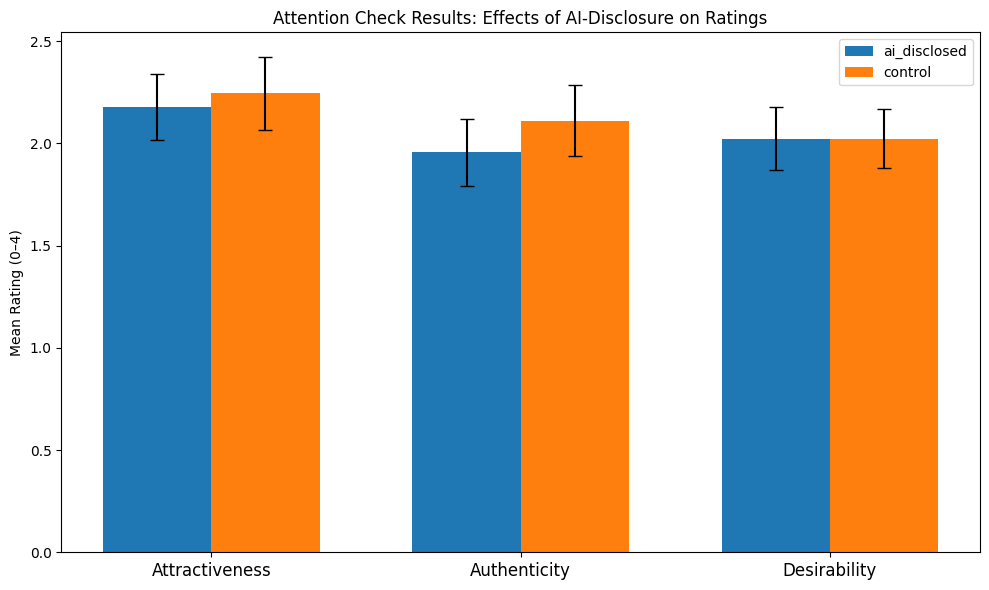

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# -------------------------------------------------------------------
# 2. Keep only participants with exactly 11 responses
# -------------------------------------------------------------------
participant_counts = df.groupby("participant_id").size()
full_ids = participant_counts[participant_counts == 11].index

full_responses_df = df[df["participant_id"].isin(full_ids)].copy()

# Count distinct participants by attraction category
attraction_counts = (
    full_responses_df
    .groupby("attraction")["participant_id"]
    .nunique()
)

print(attraction_counts)

# -------------------------------------------------------------------
# 3. Filter: only attention check rows (Maybe in the future also just if the attention check was passed)
# -------------------------------------------------------------------
attn_df = full_responses_df[full_responses_df["profile_id"] != "attention_check"].copy()



# -------------------------------------------------------------------
# 4. Grouping (your requirement)
# -------------------------------------------------------------------
attn_counts = (
    attn_df
    .groupby(["profile_id", "condition"])
    .size()
    .unstack(fill_value=0)
)

print("Counts:")
print(attn_counts)

# -------------------------------------------------------------------
# 5. FIGURE: Effects of AI-Disclosure using ONLY attention-check data
# -------------------------------------------------------------------
dvs = ["attractiveness", "authenticity", "desirability"]

# Compute means + SEM per condition
summary = attn_df.groupby("condition")[dvs].agg(['mean', 'sem'])

print("\nSummary stats:")
print(summary)

conditions = summary.index.tolist()
x = np.arange(len(dvs))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))

# Bar plot for each condition
for i, condition in enumerate(conditions):
    means = summary.loc[condition, (dvs, "mean")].values
    errors = summary.loc[condition, (dvs, "sem")].values

    ax.bar(
        x + i*width - width/2,
        means,
        width,
        yerr=errors,
        capsize=5,
        label=condition
    )

# Labels, formatting
ax.set_xticks(x)
ax.set_xticklabels(["Attractiveness", "Authenticity", "Desirability"], fontsize=12)
ax.set_ylabel("Mean Rating (0–4)")
ax.set_title("Attention Check Results: Effects of AI-Disclosure on Ratings")
ax.legend()

plt.tight_layout()
plt.show()
